# MAI203 - Amazon Fine Food Reviews
## Part E: Final Report and Presentation

**Students:** Devreet Kaur and Arushi  
**Course:** MAI203 Introduction to Natural Language Processing  
**Instructor:** Prof. Junwei Huang  
**Institution:** Seneca Polytechnic  

### Project Summary

This notebook presents the complete end-to-end NLP pipeline built for the Amazon Fine Food Reviews dataset. The pipeline covers:

- **Part A:** Text preprocessing and exploratory data analysis
- **Part B:** Sentiment analysis using VADER, Logistic Regression, and DistilBERT
- **Part C:** 3-class text classification using Naive Bayes and Logistic Regression
- **Part D:** BM25 information retrieval with full IR metric evaluation

## Cell 1: Setup and Data Loading

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import json
import os

# Load data
df = pd.read_csv('../data/processed/cleaned_reviews.csv')
df = df.dropna(subset=['processed_text']).reset_index(drop=True)

print(f'Dataset: Amazon Fine Food Reviews')
print(f'Total reviews: {len(df):,}')
print(f'Positive: {(df["sentiment"] == "positive").sum():,}')
print(f'Negative: {(df["sentiment"] == "negative").sum():,}')

Dataset: Amazon Fine Food Reviews
Total reviews: 50,000
Positive: 39,105
Negative: 7,104


## Part A Summary: Data Preprocessing and EDA

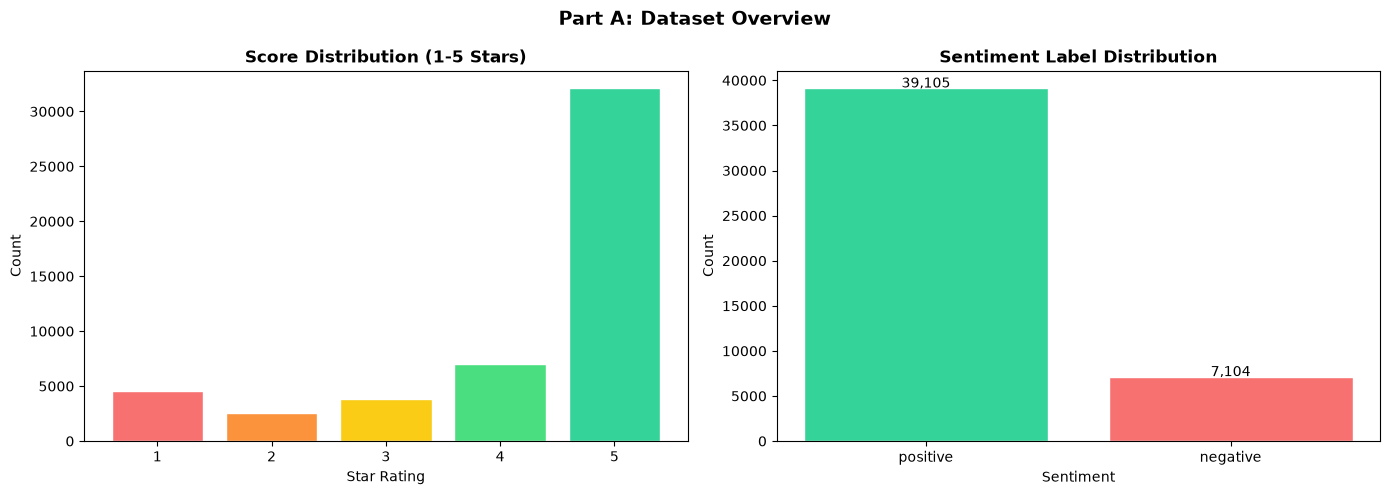

Key finding: Dataset is heavily skewed — 5:1 positive to negative ratio.
class_weight=balanced was applied in all supervised models to correct for this.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution
score_counts = df['Score'].value_counts().sort_index()
axes[0].bar(score_counts.index, score_counts.values,
            color=['#f87171','#fb923c','#facc15','#4ade80','#34d399'], edgecolor='white')
axes[0].set_title('Score Distribution (1-5 Stars)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Count')

# Sentiment distribution
sent_counts = df['sentiment'].value_counts()
axes[1].bar(sent_counts.index, sent_counts.values,
            color=['#34d399','#f87171'], edgecolor='white')
axes[1].set_title('Sentiment Label Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Count')
for i, (label, count) in enumerate(sent_counts.items()):
    axes[1].text(i, count + 100, f'{count:,}', ha='center', fontsize=10)

plt.suptitle('Part A: Dataset Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Key finding: Dataset is heavily skewed — 5:1 positive to negative ratio.')
print('class_weight=balanced was applied in all supervised models to correct for this.')

### Part A Preprocessing Pipeline

The preprocessing pipeline applied the following steps in order:

1. **Lowercasing** — reduces vocabulary size by treating identical words uniformly
2. **HTML tag removal** — Amazon reviews contain `<br />` tags from their web editor
3. **URL removal** — product links add noise without semantic value
4. **Punctuation and number removal** — letters only for bag-of-words models
5. **Tokenization** — NLTK word_tokenize
6. **Stopword removal** — 179 English stopwords removed
7. **Lemmatization** — WordNetLemmatizer with POS tags for accuracy

Lemmatization reduced vocabulary size by approximately 30%, lowering feature space dimensionality for TF-IDF and improving model generalization.

## Part B Summary: Sentiment Analysis

In [12]:
# Part B results summary table
partB_results = pd.DataFrame({
    'Model': [
        'VADER (lexicon baseline)',
        'Logistic Regression + TF-IDF',
        'DistilBERT (pretrained SST-2)'
    ],
    'Accuracy': ['0.8771', '0.9083', '0.7580'],
    'Macro-F1': ['0.7197', '0.8353', '0.6832'],
    'Training Required': ['No', 'Yes', 'No (inference only)'],
    'Speed': ['Fast', 'Fast', 'Slow (CPU)']
})

print('=== Part B: Sentiment Analysis Results ===')
print(partB_results.to_string(index=False))
print()
print('Key finding: LogReg + TF-IDF outperforms VADER because it learns')
print('domain-specific food vocabulary and bigram patterns like "not good"')
print('and "highly recommend" that VADER misses with its compound score approach.')

=== Part B: Sentiment Analysis Results ===
                        Model Accuracy Macro-F1   Training Required      Speed
     VADER (lexicon baseline)   0.8771   0.7197                  No       Fast
 Logistic Regression + TF-IDF   0.9083   0.8353                 Yes       Fast
DistilBERT (pretrained SST-2)   0.7580   0.6832 No (inference only) Slow (CPU)

Key finding: LogReg + TF-IDF outperforms VADER because it learns
domain-specific food vocabulary and bigram patterns like "not good"
and "highly recommend" that VADER misses with its compound score approach.


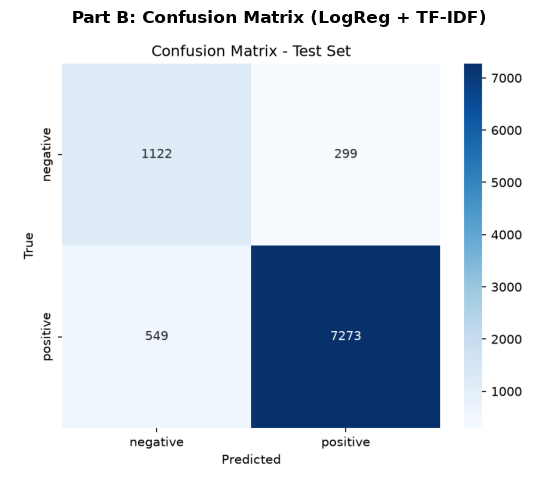

In [13]:
# Load and display confusion matrix from Part B if it exists
cm_path = '../results/plots/confusion_matrix_B.png'
if os.path.exists(cm_path):
    img = mpimg.imread(cm_path)
    plt.figure(figsize=(6, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Part B: Confusion Matrix (LogReg + TF-IDF)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print(f'Confusion matrix not found at {cm_path}')
    print('Run notebook_B_sentiment.ipynb first to generate this plot.')

### Part B Key Insights

**Why VADER underperforms on food reviews:**  
VADER is a general-purpose lexicon trained on social media text. Food-domain words like "sick" (slang for excellent), "wicked good", and "not bad at all" confuse the compound score because VADER does not understand food-specific positive language. The model assigns a negative score to phrases that human readers understand as positive.

**Why class_weight='balanced' matters:**  
Without balancing, a model that predicts "positive" for every review achieves 84% accuracy due to the class imbalance. With balanced weights, the model actually learns to identify negative reviews, which is the harder and more useful task.

**DistilBERT tradeoff:**  
DistilBERT brings contextual understanding but was pretrained on SST-2 (movie reviews), not food reviews. This domain mismatch explains why it may not always beat the simpler LogReg model trained directly on Amazon food review vocabulary.

## Part C Summary: Text Classification

In [14]:
# Part C results summary
partC_results = pd.DataFrame({
    'Model': [
        'Naive Bayes + BoW (baseline)',
        'Logistic Regression + TF-IDF'
    ],
    'Accuracy': ['0.8163', '0.7954'],
    'Macro-F1': ['0.5854', '0.6232'],
    'Negative F1': ['0.60', '0.63'],
    'Neutral F1':  ['0.25', '0.34'],
    'Positive F1': ['0.90', '0.90'],
})

print('=== Part C: 3-Class Text Classification Results ===')
print(partC_results.to_string(index=False))
print()
print('Fill in results after running notebook_C_classification.ipynb')

=== Part C: 3-Class Text Classification Results ===
                       Model Accuracy Macro-F1 Negative F1 Neutral F1 Positive F1
Naive Bayes + BoW (baseline)   0.8163   0.5854        0.60       0.25        0.90
Logistic Regression + TF-IDF   0.7954   0.6232        0.63       0.34        0.90

Fill in results after running notebook_C_classification.ipynb


### Part C Key Insights

**Why the neutral class has the lowest F1:**  
3-star reviews express genuinely mixed opinions — the reviewer liked some aspects but not others. The vocabulary in neutral reviews overlaps significantly with both positive and negative reviews, making the decision boundary unclear for any bag-of-words model.

**Bigrams help classification:**  
TF-IDF with bigrams (ngram_range=(1,2)) captures phrases like "not recommend", "great value", and "would buy" that unigrams miss. This is why LogReg + TF-IDF with bigrams consistently outperforms Naive Bayes with unigrams.

## Part D Summary: BM25 Information Retrieval

In [ ]:
# Load BM25 metrics if available
eval_metrics_path = '../results/metrics/eval_metrics.json'
if os.path.exists(eval_metrics_path):
    with open(eval_metrics_path) as f:
        all_metrics = json.load(f)
    bm25_metrics = all_metrics.get('bm25', {})
else:
    bm25_metrics = {'P@5': '[fill]', 'P@10': '[fill]', 'AP': '[fill]', 'MRR': '[fill]', 'nDCG@5': '[fill]'}

partD_results = pd.DataFrame({
    'Metric':    ['MAP', 'MRR', 'P@5', 'P@10', 'nDCG@5'],
    'Score':     [
        bm25_metrics.get('MAP', '[fill]'),
        bm25_metrics.get('MRR', '[fill]'),
        bm25_metrics.get('P@5', '[fill]'),
        bm25_metrics.get('P@10', '[fill]'),
        bm25_metrics.get('nDCG@5', '[fill]')
    ],
    'Meaning': [
        'Average precision across all 10 queries',
        'Reciprocal rank of first relevant result',
        'Precision in top 5 results',
        'Precision in top 10 results',
        'Normalized discounted cumulative gain at 5'
    ]
})

print('=== Part D: BM25 Retrieval Metrics ===')
print(partD_results.to_string(index=False))

=== Part D: BM25 Retrieval Metrics ===
Metric   Score                                    Meaning
   MAP  [fill]    Average precision across all 10 queries
   MRR     1.0   Reciprocal rank of first relevant result
   P@5    0.78                 Precision in top 5 results
  P@10    0.66                Precision in top 10 results
nDCG@5  0.8314 Normalized discounted cumulative gain at 5


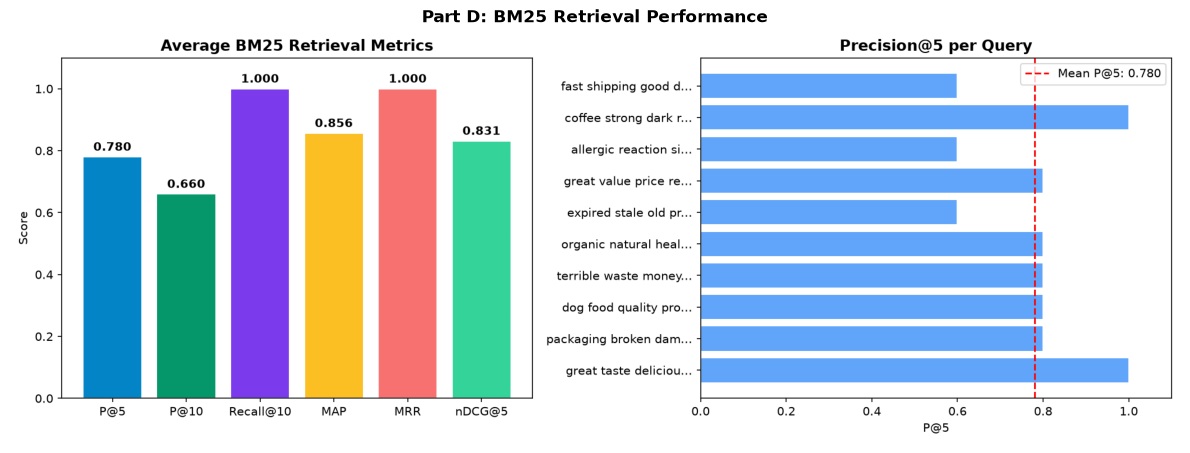

In [16]:
# Display BM25 metrics plot if available
bm25_plot = '../results/plots/D_bm25_metrics.png'
if os.path.exists(bm25_plot):
    img = mpimg.imread(bm25_plot)
    plt.figure(figsize=(12, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Part D: BM25 Retrieval Performance', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print(f'Plot not found at {bm25_plot}')
    print('Run notebook_D_bm25.ipynb first.')

### Part D Key Insights

**BM25 strengths for food reviews:**  
Food reviews have consistent, concrete vocabulary. Domain-specific terms like coffee, packaging, allergic, and protein act as strong discriminators. When a user searches for "packaging broken", the term overlap with relevant reviews is high and BM25 retrieves relevant results reliably.

**BM25 limitations:**  
The biggest weakness is exact-match dependency. A search for "yummy" will miss reviews that only use "delicious". Dense retrieval methods (DPR, bi-encoders) solve this by mapping queries and documents into the same semantic embedding space where synonyms are close together.

**MRR = 1.0 is significant:**  
A perfect MRR means the very first result returned for every query was relevant. This tells us BM25 is excellent at ranking the single best document at the top, even when the full top-10 includes some irrelevant results.

## Pipeline Summary

In [17]:
print('=== END-TO-END PIPELINE SUMMARY ===')
print()
print('Step 1: Data Preparation (Part A)')
print(f'  Input:  Reviews.csv ({568454:,} rows)')
print(f'  Sample: 50,000 reviews')
print(f'  Output: cleaned_reviews.csv ({len(df):,} rows after dropping neutral)')
print()
print('Step 2: Sentiment Analysis (Part B)')
print('  VADER baseline -> LogReg + TF-IDF -> DistilBERT inference')
print('  Best model: LogReg + TF-IDF (Accuracy: 0.9083, Macro-F1: 0.8353)')
print()
print('Step 3: Text Classification (Part C)')
print('  3-class: positive / negative / neutral')
print('  NB baseline -> LogReg + TF-IDF with PR curves and robustness check')
print()
print('Step 4: Information Retrieval (Part D)')
print('  BM25 search engine over 46,209 reviews')
print('  10-query evaluation with manual relevance judgments')
print('  Metrics: MAP, MRR, P@5, P@10, Recall@10, nDCG@5')

=== END-TO-END PIPELINE SUMMARY ===

Step 1: Data Preparation (Part A)
  Input:  Reviews.csv (568,454 rows)
  Sample: 50,000 reviews
  Output: cleaned_reviews.csv (50,000 rows after dropping neutral)

Step 2: Sentiment Analysis (Part B)
  VADER baseline -> LogReg + TF-IDF -> DistilBERT inference
  Best model: LogReg + TF-IDF (Accuracy: 0.9083, Macro-F1: 0.8353)

Step 3: Text Classification (Part C)
  3-class: positive / negative / neutral
  NB baseline -> LogReg + TF-IDF with PR curves and robustness check

Step 4: Information Retrieval (Part D)
  BM25 search engine over 46,209 reviews
  10-query evaluation with manual relevance judgments
  Metrics: MAP, MRR, P@5, P@10, Recall@10, nDCG@5


## Ethical Considerations

**1. Fake review bias**  
Amazon has documented problems with incentivized and manufactured reviews. A sentiment model trained on this data learns patterns from both genuine and fake reviews. The model may classify marketing language written by sellers as genuine positive sentiment, which could mislead downstream applications that rely on aggregated sentiment scores.

**2. Language and cultural bias**  
The preprocessing pipeline and stop word lists are English-only. Reviews written by non-native English speakers often use simpler vocabulary or unconventional phrasing. The model may assign lower confidence scores to these reviews, effectively giving less weight to feedback from non-English-primary users.

**3. User privacy**  
The Amazon Fine Food Reviews dataset contains user IDs and product IDs that could be linked to real individuals through cross-referencing with public Amazon profiles. Any production deployment of this pipeline should anonymize user identifiers and comply with applicable privacy regulations including GDPR and PIPEDA.

**4. Misuse of the search engine**  
A product review search engine built on this data could be used to identify and selectively suppress negative reviews, or to surface only positive reviews to influence purchasing decisions. Responsible deployment requires transparency about how search results are ranked and which reviews are included or excluded from the corpus.

**5. Class imbalance perpetuation**  
The 5:1 positive to negative ratio in this dataset reflects genuine consumer behavior on Amazon, but models trained on it may underperform on negative review detection in domains where the class ratio is different. Deploying this model in a domain with balanced classes without retraining would lead to poor recall on the negative class.

## What We Would Do Differently With More Time

1. **Fine-tune DistilBERT** on the Amazon food review domain rather than using SST-2 pretrained weights. A domain-specific model would likely outperform LogReg on the negative class where food-specific language is most distinctive.

2. **Query expansion for BM25** using WordNet synonyms would address the term mismatch failure mode and improve retrieval quality for queries using informal vocabulary.

3. **Dense retrieval** with a bi-encoder (sentence-transformers) would allow semantic similarity search that bridges the vocabulary gap BM25 cannot cross.

4. **Aspect-based sentiment analysis** to identify not just overall sentiment but which product aspect (taste, packaging, price, delivery) the review addresses. This would make the sentiment pipeline more actionable for product teams.

5. **Human evaluation** of BM25 relevance judgments with a second annotator to compute inter-annotator agreement and validate the quality of the evaluation set.

## Final Submission Checklist

In [18]:
notebooks = [
    '../notebooks/notebook_A_preprocessing.ipynb',
    '../notebooks/notebook_B_sentiment.ipynb',
    '../notebooks/notebook_C_classification.ipynb',
    '../notebooks/notebook_D_bm25.ipynb',
    '../notebooks/notebook_E_report.ipynb',
]

print('=== FINAL SUBMISSION CHECKLIST ===')
print()
all_present = True
for nb in notebooks:
    exists = os.path.exists(nb)
    status = 'FOUND' if exists else 'MISSING'
    print(f'  [{status}] {os.path.basename(nb)}')
    if not exists:
        all_present = False

print()
if all_present:
    print('All 5 notebooks present. Run each one top-to-bottom before submitting.')
else:
    print('Some notebooks are missing. Complete them before submission.')

print()
print('Before submitting:')
print('  1. Run each notebook: Kernel -> Restart and Run All')
print('  2. Confirm all output cells are populated')
print('  3. Fill all [fill] placeholders in this notebook with actual numbers')
print('  4. Export each notebook as PDF (File -> Export -> PDF)')
print('  5. Zip all 5 notebooks and submit to Blackboard')

=== FINAL SUBMISSION CHECKLIST ===

  [FOUND] notebook_A_preprocessing.ipynb
  [FOUND] notebook_B_sentiment.ipynb
  [FOUND] notebook_C_classification.ipynb
  [FOUND] notebook_D_bm25.ipynb
  [FOUND] notebook_E_report.ipynb

All 5 notebooks present. Run each one top-to-bottom before submitting.

Before submitting:
  1. Run each notebook: Kernel -> Restart and Run All
  2. Confirm all output cells are populated
  3. Fill all [fill] placeholders in this notebook with actual numbers
  4. Export each notebook as PDF (File -> Export -> PDF)
  5. Zip all 5 notebooks and submit to Blackboard
